In [102]:
import pandas as pd
emails = pd.read_csv("enron_practical_sample.csv")
emails

,text,label
0,"hello scott ,\nyour request is complete as fol...",ham
1,this will clear your inbox\nof spam and porn !...,spam
2,team :\nwe are fast approaching our june 1 dat...,ham
3,here are the current issues related to var and...,ham
4,"to all women ,\nif your not satisfied with you...",spam
...,...,...
1995,thanks for clarifying that vince .\nvince j ka...,ham
1996,- - - - - - - - - - - - - - - - - - - - - - - ...,ham
1997,greetings\nintruducing m i\nenjoy these great ...,spam
1998,"yes , i sent a reply to gillian .\n- - stinson",ham


In [2]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    emails,
    train_size=0.10,
    stratify=emails["label"],
    random_state=2025
)
train_text = train_df["text"]
train_labels = train_df["label"]
test_text = test_df["text"]
test_labels = test_df["label"]
print(train_labels.value_counts())
print(test_labels.value_counts())


label
ham     100
spam    100
Name: count, dtype: int64
label
spam    900
ham     900
Name: count, dtype: int64


# Part B

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# vectoriser = TfidfVectorizer(stop_words="english", ngram_range=(3, 5), analyzer="char_wb")
vectoriser = TfidfVectorizer(stop_words="english", ngram_range=(3, 5), min_df=2, max_df=0.8)
X_train = vectoriser.fit_transform(train_text)

In [4]:
# Vocabulary size
vocab_size = len(vectoriser.vocabulary_)
print(f"Vocabulary size: {vocab_size}")
# Top 10 weighted terms (highest IDF scores)
idf_series = pd.Series(vectoriser.idf_, index=vectoriser.get_feature_names_out())
top_10_terms = idf_series.nlargest(10)
print("\nTop 10 weighted terms:")
print(top_10_terms)


Vocabulary size: 2124

Top 10 weighted terms:
001 torre quadro               5.204693
001 torre quadro hyster        5.204693
001 torre quadro hyster 150    5.204693
002 torre quadro               5.204693
002 torre quadro hyster        5.204693
002 torre quadro hyster 225    5.204693
003 tra hyster                 5.204693
003 tra hyster 225             5.204693
003 tra hyster 225 10          5.204693
005 sua empresa                5.204693
dtype: float64


# Part C

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import matplotlib.pyplot as plt
import seaborn as sns
# Vectorize with moderate feature budget
vectoriser = TfidfVectorizer(max_features=1000, stop_words="english", ngram_range=(1, 5), min_df=4, max_df=0.8)
X_tfidf = vectoriser.fit_transform(train_text)
# Reduce to 2D with UMAP
reducer = umap.UMAP(n_components=2, random_state=2025, n_neighbors=20, metric='cosine')
embedding = reducer.fit_transform(X_tfidf)


C:\Users\ryanw\Documents\GitHub\Uni-Work\PhD\Teaching\2026\COMP2200\Semester 1\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


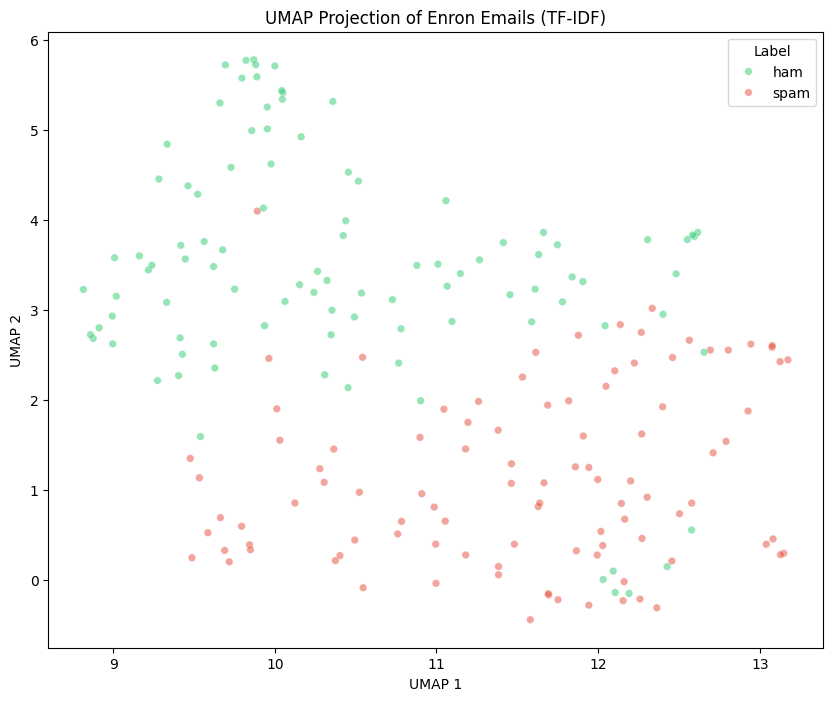

In [61]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1],
hue=train_labels, palette=["#2ecc71", "#e74c3c"],
alpha=0.5, s=30)
plt.title("UMAP Projection of Enron Emails (TF-IDF)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Label")
plt.show()

# Part D

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("vectoriser", TfidfVectorizer(max_features=1000, stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ("model", LogisticRegression(max_iter=500))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2025)
metrics = cross_validate(pipeline, train_text, train_labels, cv=cv, scoring=["accuracy", "f1_macro"], return_train_score=True)
metrics

{'fit_time': array([0.06995702, 0.05494022, 0.05977964, 0.04601216, 0.04642081]),
 'score_time': array([0.00700116, 0.00712323, 0.00799823, 0.01085591, 0.01030135]),
 'test_accuracy': array([0.95 , 1.   , 0.875, 1.   , 0.95 ]),
 'train_accuracy': array([0.9875 , 0.98125, 0.9875 , 0.975  , 0.975  ]),
 'test_f1_macro': array([0.94987469, 1.        , 0.87301587, 1.        , 0.94987469]),
 'train_f1_macro': array([0.98749805, 0.98124341, 0.98749805, 0.97498437, 0.97498437])}

In [76]:
print(metrics["test_f1_macro"].mean() )
print(metrics["test_accuracy"].mean())

0.9545530492898914
0.9550000000000001


In [77]:
pipeline.fit(train_text, y=train_labels)

,steps,"[('vectoriser', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


0.9294444444444444 0.9294285658717656


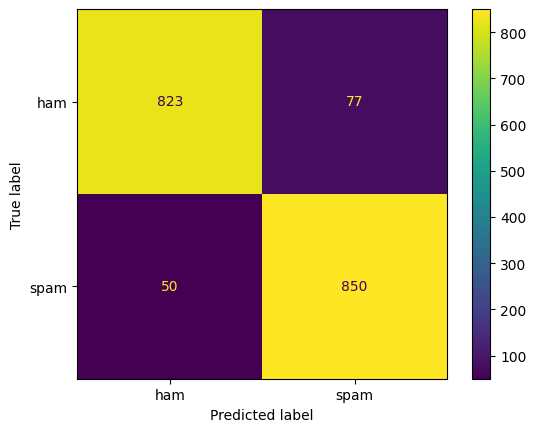

In [117]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

predictions = pipeline.predict(test_text)

acc = pipeline.score(test_text, y=test_labels, scoring='accuracy')
f1 = f1_score(test_labels, predictions, average='macro')

print(acc, f1)

matrix = confusion_matrix(test_labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=pipeline['model'].classes_)

disp.plot()

# Part E

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import Bunch
import numpy as np

best_params = {
    "max_features": 1000,
    "stop_words": "english",
    "min_df": 5, 
    "max_df": 0.8, 
    "ngram_range": (1, 2)
}

In [81]:
def train_with_c(C=1.0, penalty="l2") -> Bunch:
    pipeline = Pipeline([("vectoriser", TfidfVectorizer(**best_params)),
                         ("model", LogisticRegression(max_iter=1000, C=C, penalty=penalty,
                                                      solver="liblinear" if penalty == "l1" else "lbfgs"))])
    
    pipeline.fit(train_text, train_labels)
    return Bunch(pipeline=pipeline,
                 coefficients=pipeline.named_steps["model"].coef_[0],
                 vocab=pipeline.named_steps["vectoriser"].get_feature_names_out())


In [82]:
C_trials = [0.1, 1, 10, 1]
penalties = ['l2', 'l2', 'l2', 'l1']

plot_labels = ['C=0.1\np=l2', 'C=1\np=l2', 'C=10\np=l2', 'C=1\np=l1']

bunches = []

for i, [c, penalty] in enumerate(zip(C_trials, penalties)):
    print(i)
    bunches.append(train_with_c(C=c, penalty=penalty))

0
1
2
3


In [83]:
bunches[0]

{'pipeline': Pipeline(steps=[('vectoriser',
                  TfidfVectorizer(max_df=0.8, max_features=1000, min_df=5,
                                  ngram_range=(1, 2), stop_words='english')),
                 ('model', LogisticRegression(C=0.1, max_iter=1000))]),
 'coefficients': array([-3.73961068e-02, -5.66159603e-02, -7.33920168e-02, -1.59672593e-02,
        -3.55591026e-02, -6.25075709e-02, -2.45254649e-02, -2.54993048e-02,
        -2.45932526e-02,  3.01926009e-02, -2.05682740e-02,  1.53062144e-02,
         4.86166962e-02, -9.52930207e-02, -7.13058118e-02,  8.84898593e-03,
        -1.24322960e-02,  1.48384804e-02, -1.99428773e-02, -5.27540962e-02,
         2.07011900e-02, -1.75015088e-02, -1.14541151e-02, -1.16124867e-02,
        -2.71187421e-02, -6.22175774e-02,  1.09629206e-02, -1.06414477e-01,
        -1.44781911e-02, -3.23619622e-02, -2.86400352e-02, -1.80812693e-01,
         3.15746569e-02,  1.03188810e-01,  5.33945853e-03, -3.28256300e-02,
        -3.76601392e-02,  5.737

enron


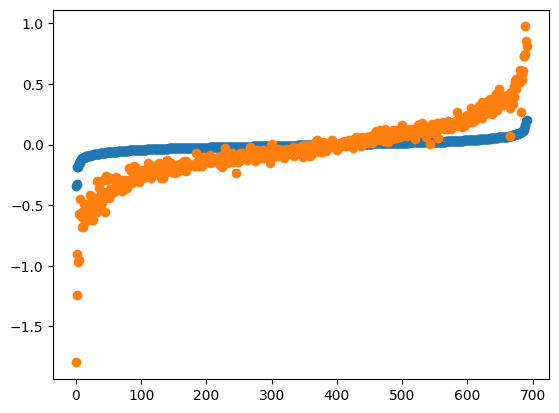

In [91]:
fig, ax = plt.subplots()

# first iter: C = 0.1, penalty = l2 - blue
# second iter: C = 1, penalty = l2 - orange

for i in range(2):
    ydata = bunches[i]['coefficients']

    if i == 0:
        sort_inds = np.argsort(ydata)
    # sort_inds = np.argsort(ydata)
    # print(len(ydata))
    
    plt.scatter(np.arange(len(ydata)), ydata[sort_inds])

print(bunches[0]['vocab'][sort_inds[0]])

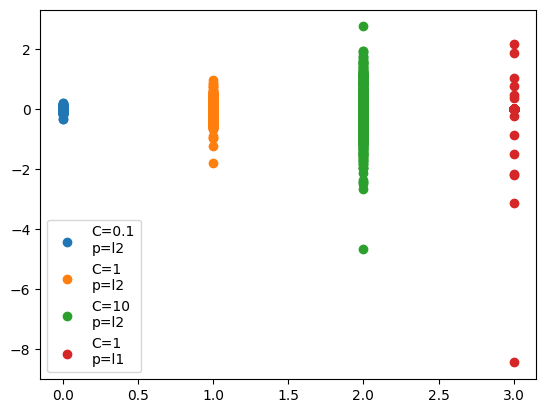

In [92]:
fig, ax = plt.subplots()

for i in range(4):
    ax.scatter(i * np.ones(len(bunches[i]['coefficients'])), bunches[i]['coefficients'], label=plot_labels[i])
ax.legend()

In [93]:
winner = bunches[-1]

In [94]:
sorted_inds = np.argsort(winner['coefficients']).flatten()

lowest_inds = sorted_inds[:5]
highest_inds = sorted_inds[-5:]

lowest_coeffs = winner['coefficients'][lowest_inds]
lowest_values = winner['vocab'][lowest_inds]

highest_coeffs = winner['coefficients'][highest_inds]
highest_values = winner['vocab'][highest_inds]

print(lowest_coeffs, lowest_values)
print(highest_coeffs, highest_values)

[-8.43524054 -3.12906377 -2.18626136 -2.18285246 -1.50885879] ['enron' '2001' 'ect' 'attached' 'vince']
[0.46318919 0.75116781 1.01474235 1.85894319 2.16789475] ['site' 'http' 'adobe' 'money' 'com']


# Part F

In [95]:
probabilities = pipeline.predict_proba(test_text)

probabilities

array([[0.31387071, 0.68612929],
       [0.32346849, 0.67653151],
       [0.36142808, 0.63857192],
       ...,
       [0.53467382, 0.46532618],
       [0.32990106, 0.67009894],
       [0.43036418, 0.56963582]], shape=(1800, 2))

In [106]:
misclass_inds = predictions != test_labels.values

prob_spam = np.array(probabilities[misclass_inds])[:, 1]

misclassifications = pd.DataFrame({'text': test_text[misclass_inds],
                                  'true_label': test_labels.values[misclass_inds],
                                  'predicted': predictions[misclass_inds],
                                  'probability': prob_spam}).reset_index()
misclassifications

print(misclassifications['predicted'].value_counts())

predicted
spam    77
ham     50
Name: count, dtype: int64
